# Python Advanced Topics 2

1. Using "concurrent" Module for parallel processing
2. Object Classes and Instances
3. Recursion
4. Decorators
5. Using "glog" Module for logging & Performance Testing
6. Using "Functools" Module for memoization


## 1. Using "concurrent" Module for parallel processing

### 1.1 Concurrent Procsses Example 1

In [ ]:
import concurrent.futures
import time


def do_something(seconds):
    print(f'Sleeping {seconds} second(s)...')
    time.sleep(seconds)
    return f'Done Sleeping...{seconds}'

def main():
    start = time.perf_counter()

    # spawning multiple processes using context manager
    with concurrent.futures.ProcessPoolExecutor() as executor:
        secs = [5, 4, 3, 2, 1]

        try:
            # using map
            results = executor.map(do_something, secs)
            for result in results:
                print(result)
        except Exception as e:
            print(e)

    finish = time.perf_counter()

    print(f'Finished in {round(finish-start, 2)} second(s)')

if __name__ == '__main__':
    main()


A process in the process pool was terminated abruptly while the future was running or pending.
Finished in 0.07 second(s)


Process SpawnProcess-13:
Process SpawnProcess-12:
Process SpawnProcess-14:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/michaelkao/miniconda3/envs/pex/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/michaelkao/miniconda3/envs/pex/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/michaelkao/miniconda3/envs/pex/lib/python3.13/concurrent/futures/process.py", line 242, in _process_worker
    call_item = call_queue.get(block=True)
  File "/Users/michaelkao/miniconda3/envs/pex/lib/python3.13/multiprocessing/queues.py", line 120, in get
    return _ForkingPickler.loads(res)
           ~~~~~~~~~~~~~~~~~~~~~^^^^^
AttributeError: Can't get attribute 'do_something' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>
  File "/U

In [ ]:
import concurrent.futures
import time


def do_something(seconds):
    print(f'Sleeping {seconds} second(s)...')
    time.sleep(seconds)
    return f'Done Sleeping...{seconds}'


def main():
    start = time.perf_counter()

    with concurrent.futures.ProcessPoolExecutor() as executor:
        secs = [5, 4, 3, 2, 1]

        # using List comprehession
        results = [executor.submit(do_something, sec) for sec in secs]
        for f in concurrent.futures.as_completed(results):
            print(f.result())

    finish = time.perf_counter()

    print(f'Finished in {round(finish-start, 2)} second(s)')

if __name__ == '__main__':
    main()



Process SpawnProcess-2:
Process SpawnProcess-1:
Traceback (most recent call last):
Traceback (most recent call last):
Process SpawnProcess-4:
  File "/Users/michaelkao/miniconda3/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/michaelkao/miniconda3/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/michaelkao/miniconda3/lib/python3.13/concurrent/futures/process.py", line 242, in _process_worker
    call_item = call_queue.get(block=True)
  File "/Users/michaelkao/miniconda3/lib/python3.13/multiprocessing/queues.py", line 120, in get
    return _ForkingPickler.loads(res)
           ~~~~~~~~~~~~~~~~~~~~~^^^^^
AttributeError: Can't get attribute 'do_something' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>
  File "/Users/michaelkao/miniconda3/lib/python3.13/multiprocessing/process.py", lin

BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

#### AttributeError Workaround 1

Re: With Jupyter Notebook, Can't get attribute 'do_something'... The key changes:

1. Added if __name__ == '__main__': guard to prevent the code from running when imported as a module
2. Wrapped the main execution in a function and called it under the if __name__ == '__main__' block
3. Added list() around executor.map() to ensure all results are processed before continuing

In [ ]:
import concurrent.futures
import time

def do_something(seconds):
    print(f'Sleeping {seconds} second(s)...')
    time.sleep(seconds)
    return f'Done Sleeping...{seconds}'

def main():
    start = time.perf_counter()

    # Important: Define the function at the module level
    # and use __name__ == '__main__' guard
    if __name__ == '__main__':
        with concurrent.futures.ProcessPoolExecutor() as executor:
            secs = [5, 4, 3, 2, 1]
            
            # Using map
            results = list(executor.map(do_something, secs))
            for result in results:
                print(result)

        finish = time.perf_counter()
        print(f'Finished in {round(finish-start, 2)} second(s)')

if __name__ == '__main__':
    main()

Process SpawnProcess-10:
Process SpawnProcess-7:
Process SpawnProcess-6:
Process SpawnProcess-8:
Process SpawnProcess-9:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/michaelkao/miniconda3/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/michaelkao/miniconda3/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/michaelkao/miniconda3/lib/python3.13/concurrent/futures/process.py", line 242, in _process_worker
    call_item = call_queue.get(block=True)
  File "/Users/michaelkao/miniconda3/lib/python3.13/multiprocessing/queues.py", line 120, in get
    return _ForkingPickler.loads(res)
           ~~~~~~~~~~~~~~~~~~~~~^^^^^
  File "/Users/michaelkao/miniconda3/lib/python3.1

BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

#### AttributeError Workaround 2

Using threads instead of processes avoids the pickling issues with jupyter notebook.

In [ ]:
import concurrent.futures
import time

def do_something(seconds):
    print(f'Sleeping {seconds} second(s)...')
    time.sleep(seconds)
    return f'Done Sleeping...{seconds}'

start = time.perf_counter()

with concurrent.futures.ThreadPoolExecutor() as executor:
    secs = [5, 4, 3, 2, 1]
    results = list(executor.map(do_something, secs))
    for result in results:
        print(result)

finish = time.perf_counter()
print(f'Finished in {round(finish-start, 2)} second(s)')

Sleeping 5 second(s)...Sleeping 4 second(s)...

Sleeping 3 second(s)...
Sleeping 2 second(s)...
Sleeping 1 second(s)...
Done Sleeping...5
Done Sleeping...4
Done Sleeping...3
Done Sleeping...2
Done Sleeping...1
Finished in 5.01 second(s)


### 1.2 Concurrent Procsses Example 2

In [6]:
# Parallel processing with mutiple processes
import time
import concurrent.futures
from PIL import Image, ImageFilter

img_names = [
    'photo-1516117172878-fd2c41f4a759.jpg',
    'photo-1532009324734-20a7a5813719.jpg',
    'photo-1524429656589-6633a470097c.jpg',
    'photo-1530224264768-7ff8c1789d79.jpg',
    'photo-1564135624576-c5c88640f235.jpg',
    'photo-1541698444083-023c97d3f4b6.jpg',
    'photo-1522364723953-452d3431c267.jpg',
    'photo-1513938709626-033611b8cc03.jpg',
    'photo-1507143550189-fed454f93097.jpg',
    'photo-1493976040374-85c8e12f0c0e.jpg',
    'photo-1504198453319-5ce911bafcde.jpg',
    'photo-1530122037265-a5f1f91d3b99.jpg',
    'photo-1516972810927-80185027ca84.jpg',
    'photo-1550439062-609e1531270e.jpg',
    'photo-1549692520-acc6669e2f0c.jpg'
]

size = (1200, 1200)


def process_image(img_name):
    img = Image.open(img_name)

    img = img.filter(ImageFilter.GaussianBlur(15))

    img.thumbnail(size)
    img.save(f'img_processed/{img_name}')
    print(f'{img_name} was processed...')


def main():
    t1 = time.perf_counter()

    with concurrent.futures.ProcessPoolExecutor() as executor:

        executor.map(process_image, img_names)

    t2 = time.perf_counter()

    print(f'Finished in {t2-t1} seconds')

if __name__ == '__main__':
    main()



Finished in 0.07647312496555969 seconds


Process SpawnProcess-15:
Process SpawnProcess-16:
Process SpawnProcess-19:
Process SpawnProcess-17:
Process SpawnProcess-18:
Process SpawnProcess-22:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/michaelkao/miniconda3/envs/pex/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/michaelkao/miniconda3/envs/pex/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/michaelkao/miniconda3/envs/pex/lib/python3.13/concurrent/futures/process.py", line 242, in _process_worker
    call_item = call_queue.get(block=True)
  File "/Users/michaelkao/miniconda3/envs/pex/lib/python3.13/multiprocessing/queues.py", line 120, in get
    return _ForkingPickler

### 1.3 Concurrent Threads Example

In [ ]:
# Parallel processing with mutiple threads
import time
import concurrent.futures
from PIL import Image, ImageFilter

img_names = [
    'photo-1516117172878-fd2c41f4a759.jpg',
    'photo-1532009324734-20a7a5813719.jpg',
    'photo-1524429656589-6633a470097c.jpg',
    'photo-1530224264768-7ff8c1789d79.jpg',
    'photo-1564135624576-c5c88640f235.jpg',
    'photo-1541698444083-023c97d3f4b6.jpg',
    'photo-1522364723953-452d3431c267.jpg',
    'photo-1513938709626-033611b8cc03.jpg',
    'photo-1507143550189-fed454f93097.jpg',
    'photo-1493976040374-85c8e12f0c0e.jpg',
    'photo-1504198453319-5ce911bafcde.jpg',
    'photo-1530122037265-a5f1f91d3b99.jpg',
    'photo-1516972810927-80185027ca84.jpg',
    'photo-1550439062-609e1531270e.jpg',
    'photo-1549692520-acc6669e2f0c.jpg'
]
size = (1200, 1200)



def process_image(img_name):
    # Open image file in ./photo folder
    try:
        img = Image.open(f'photo/{img_name}')
    except FileNotFoundError:
        print(f'{img_name} not found!')
        return

    img = img.filter(ImageFilter.GaussianBlur(15))

    img.thumbnail(size)
    img.save(f'img_processed/{img_name}')
    print(f'{img_name} was processed...')


def main():
    t1 = time.perf_counter()

    # Spawning threads, instead of processes
    with concurrent.futures.ThreadPoolExecutor() as executor:
        executor.map(process_image, img_names)

    t2 = time.perf_counter()

    print(f'Finished in {t2-t1} seconds')

if __name__ == '__main__':
    main()


photo-1516117172878-fd2c41f4a759.jpg was processed...
photo-1507143550189-fed454f93097.jpg was processed...
photo-1516972810927-80185027ca84.jpg was processed...
photo-1522364723953-452d3431c267.jpg was processed...
photo-1524429656589-6633a470097c.jpg was processed...
photo-1530122037265-a5f1f91d3b99.jpg was processed...
photo-1532009324734-20a7a5813719.jpg was processed...
photo-1530224264768-7ff8c1789d79.jpg was processed...
photo-1564135624576-c5c88640f235.jpg was processed...
photo-1550439062-609e1531270e.jpg was processed...
photo-1513938709626-033611b8cc03.jpg was processed...
photo-1549692520-acc6669e2f0c.jpg was processed...
photo-1541698444083-023c97d3f4b6.jpg was processed...
photo-1504198453319-5ce911bafcde.jpg was processed...
photo-1493976040374-85c8e12f0c0e.jpg was processed...
Finished in 1.7797546249930747 seconds


#### AttributeError Workaround 3

Instead of using threads, running the script with python directly instead of jupyter notebook. 
For example,

```python
python -u "/Users/michaelkao/My_Projects/Python/process_images_CP.py"
```


### 1.4 Comparing Single Process Example

In [ ]:
# Single process mode
import time
import concurrent.futures
from PIL import Image, ImageFilter

img_names = [
    'photo-1516117172878-fd2c41f4a759.jpg',
    'photo-1532009324734-20a7a5813719.jpg',
    'photo-1524429656589-6633a470097c.jpg',
    'photo-1530224264768-7ff8c1789d79.jpg',
    'photo-1564135624576-c5c88640f235.jpg',
    'photo-1541698444083-023c97d3f4b6.jpg',
    'photo-1522364723953-452d3431c267.jpg',
    'photo-1513938709626-033611b8cc03.jpg',
    'photo-1507143550189-fed454f93097.jpg',
    'photo-1493976040374-85c8e12f0c0e.jpg',
    'photo-1504198453319-5ce911bafcde.jpg',
    'photo-1530122037265-a5f1f91d3b99.jpg',
    'photo-1516972810927-80185027ca84.jpg',
    'photo-1550439062-609e1531270e.jpg',
    'photo-1549692520-acc6669e2f0c.jpg'
]

size = (1200, 1200)
t1 = time.perf_counter()


for img_name in img_names:
    # Open image file in ./photo folder
    try:
        img = Image.open(f'photo/{img_name}')
    except FileNotFoundError:
        print(f'{img_name} not found!')
        continue
    
    img = img.filter(ImageFilter.GaussianBlur(15))

    img.thumbnail(size)
    img.save(f'img_processed/{img_name}')
    print(f'{img_name} was processed...')

t2 = time.perf_counter()

print(f'Finished in {t2-t1} seconds')


photo-1516117172878-fd2c41f4a759.jpg was processed...
photo-1532009324734-20a7a5813719.jpg was processed...
photo-1524429656589-6633a470097c.jpg was processed...
photo-1530224264768-7ff8c1789d79.jpg was processed...
photo-1564135624576-c5c88640f235.jpg was processed...
photo-1541698444083-023c97d3f4b6.jpg was processed...
photo-1522364723953-452d3431c267.jpg was processed...
photo-1513938709626-033611b8cc03.jpg was processed...
photo-1507143550189-fed454f93097.jpg was processed...
photo-1493976040374-85c8e12f0c0e.jpg was processed...
photo-1504198453319-5ce911bafcde.jpg was processed...
photo-1530122037265-a5f1f91d3b99.jpg was processed...
photo-1516972810927-80185027ca84.jpg was processed...
photo-1550439062-609e1531270e.jpg was processed...
photo-1549692520-acc6669e2f0c.jpg was processed...
Finished in 5.104405249992851 seconds


## 2. Object Classes and Instances


Python as an Object-Oriented programing language, it has classes which allow us to logically group our data and functions so that it is easy to reuse and also easy to build upon if needed. 


In [7]:
class Employee:

    def __init__(self, first, last, pay):
        self.first = first
        self.last = last
        self.email = first + '.' + last + '@email.com'
        self.pay = pay

    def fullname(self):
        return '{} {}'.format(self.first, self.last)

emp_1 = Employee('Michael', 'Kao', 50000)
emp_2 = Employee('Test', 'Employee', 60000)

print(emp_1.fullname())

print(type(emp_1))
print(f'Employe instance: {emp_1}')
print(f'Employe instance: {emp_2}')


Michael Kao
<class '__main__.Employee'>
Employe instance: <__main__.Employee object at 0x10c522ba0>
Employe instance: <__main__.Employee object at 0x10d14d6d0>


### 2.1 Class vs Instance Variables

We will see how class variables differ from instance variables and when exactly we would want to use them. 


In [8]:
class Employee:

    num_of_emps = 0
    raise_amt = 1.04

    def __init__(self, first, last, pay):
        self.first = first
        self.last = last
        self.email = first + '.' + last + '@email.com'
        self.pay = pay

        Employee.num_of_emps += 1

    def fullname(self):
        return '{} {}'.format(self.first, self.last)

    def apply_raise(self):
        self.pay = int(self.pay * self.raise_amt)

print(f'Default class variable \'raise_amt\':\t {Employee.raise_amt}')

emp_1 = Employee('Michael', 'Kao', 50000)
emp_2 = Employee('Test', 'Employee', 60000)

# setting Class variable
Employee.raise_amt = 1.05
print(f'Setting class variable \'raise_amt\':\t {Employee.raise_amt}')
print(f'Inherited from class variable \'emp_1.raise_amt\':\t {emp_1.raise_amt}')
print(f'Inherited from class variable \'emp_2.raise_amt\':\t {emp_2.raise_amt}\n')

# setting instance variable
emp_1.raise_amt = 1.06
print(f'Setting instance variable \'emp_1.raise_amt\':\t\t {emp_1.raise_amt}')
print(f'Inherited from class variable \'emp_2.raise_amt\':\t {emp_2.raise_amt}\n')

print('emp_1 symbol table:')
print(emp_1.__dict__)

print('emp_2 symbol table:')
print(emp_2.__dict__)
print()

print(f'The number of Employee class instances/objects: {Employee.num_of_emps}\n')
print('Employee symbol table:')
print(Employee.__dict__)

Default class variable 'raise_amt':	 1.04
Setting class variable 'raise_amt':	 1.05
Inherited from class variable 'emp_1.raise_amt':	 1.05
Inherited from class variable 'emp_2.raise_amt':	 1.05

Setting instance variable 'emp_1.raise_amt':		 1.06
Inherited from class variable 'emp_2.raise_amt':	 1.05

emp_1 symbol table:
{'first': 'Michael', 'last': 'Kao', 'email': 'Michael.Kao@email.com', 'pay': 50000, 'raise_amt': 1.06}
emp_2 symbol table:
{'first': 'Test', 'last': 'Employee', 'email': 'Test.Employee@email.com', 'pay': 60000}

The number of Employee class instances/objects: 2

Employee symbol table:
{'__module__': '__main__', '__firstlineno__': 1, 'num_of_emps': 2, 'raise_amt': 1.05, '__init__': <function Employee.__init__ at 0x10d1c0e00>, 'fullname': <function Employee.fullname at 0x10d1c0d60>, 'apply_raise': <function Employee.apply_raise at 0x10d1c11c0>, '__static_attributes__': ('email', 'first', 'last', 'pay'), '__dict__': <attribute '__dict__' of 'Employee' objects>, '__weakref

### 2.2 Classs vs Static Methods

Class methods can also be used as alternative constructors. 

Static methods do not take the instance or the class as the first argument. They behave just like normal functions, yet they should have some logical connection to the given class. 

We will look at some examples of both of these in order to understand both in depth.

In [9]:
class Employee:

    num_of_emps = 0
    raise_amt = 1.04

    def __init__(self, first, last, pay):
        self.first = first
        self.last = last
        self.email = first + '.' + last + '@email.com'
        self.pay = pay

        Employee.num_of_emps += 1

    def fullname(self):
        return '{} {}'.format(self.first, self.last)

    def apply_raise(self):
        self.pay = int(self.pay * self.raise_amt)

    @classmethod
    def set_raise_amt(cls, amount):
        cls.raise_amt = amount

    @classmethod
    def from_string(cls, emp_str):
        first, last, pay = emp_str.split('-')
        return cls(first, last, pay)

    @staticmethod
    def is_workday(day):
        if day.weekday() == 5 or day.weekday() == 6:
            return False
        return True

emp_1 = Employee('Michael', 'Kao', 50000)
emp_2 = Employee('Test', 'Employee', 60000)

Employee.set_raise_amt(1.05)

print(f'Employee.raise_amt = {Employee.raise_amt}\n')
print(f'emp_1.raise_amt = {emp_1.raise_amt}\n')
print(f'emp_2.raise_amt = {emp_2.raise_amt}\n')

# instantiating an Employee object from a string
emp_str_1 = 'John-Doe-70000'
emp_str_2 = 'Steve-Smith-30000'

first, last, pay = emp_str_1.split('-')

new_emp_1 = Employee(first, last, pay)
print(new_emp_1.fullname())
print(f'---> pay = {new_emp_1.pay}\n')

# alternatively instantiating an Employee using a class method
new_emp_2 = Employee.from_string(emp_str_2)
print(new_emp_2.fullname())
print(f'---> pay = {new_emp_2.pay}\n')

# static method example
import datetime
my_date = datetime.date(2016, 7, 11)

print(f'Is date of {my_date} a work day? {Employee.is_workday(my_date)}\n')

Employee.raise_amt = 1.05

emp_1.raise_amt = 1.05

emp_2.raise_amt = 1.05

John Doe
---> pay = 70000

Steve Smith
---> pay = 30000

Is date of 2016-07-11 a work day? True



### 2.3 Inheritance: Creating Subclasses

Inheritance allows us to inherit attributes and methods from a parent class. This is useful because we can create subclasses and get all of the functionality of our parents class, and have the ability to overwrite or add completely new functionality without affecting the parents class in any ways. 


In [10]:
class Employee:

    raise_amt = 1.04

    def __init__(self, first, last, pay):
        self.first = first
        self.last = last
        self.email = first + '.' + last + '@email.com'
        self.pay = pay

    def fullname(self):
        return '{} {}'.format(self.first, self.last)

    def apply_raise(self):
        self.pay = int(self.pay * self.raise_amt)


class Developer(Employee):
    raise_amt = 1.10

    def __init__(self, first, last, pay, prog_lang):
        super().__init__(first, last, pay)
        self.prog_lang = prog_lang


class Manager(Employee):

    def __init__(self, first, last, pay, employees=None):
        super().__init__(first, last, pay)
        if employees is None:
            self.employees = []
        else:
            self.employees = employees

    def add_emp(self, emp):
        if emp not in self.employees:
            self.employees.append(emp)

    def remove_emp(self, emp):
        if emp in self.employees:
            self.employees.remove(emp)

    def print_emps(self):
        for emp in self.employees:
            print('-->', emp.fullname())

# Developer's relationship
print(help(Developer))

# instantiating 2 developers
dev_1 = Developer('Michael', 'Kao', 50000, 'Python')
dev_2 = Developer('Test', 'Employee', 60000, 'Java')

print(f'dev_1 instantiated: {dev_1.fullname()}, pay = {dev_1.pay}')

# use aub-class variable of 10% instead of class variable of 4%
dev_1.apply_raise()
print(f'dev_1 pay raised: {dev_1.fullname()}, pay after raise = {dev_1.pay}')
print()

# introducing 2 built-in functions: isinheritance() and issubclass()
print(f'Is dev_1 instance of Employee? {isinstance(dev_1, Employee)}')
print(f'Is dev_1 instance of Developer? {isinstance(dev_1, Developer)}')
print(f'Is dev_1 instance of Manager? {isinstance(dev_1, Manager)}')

print(f'Is Developer subclass of Employee? {issubclass(Developer, Employee)}')
print(f'Is Developer subclass of Manager? {issubclass(Developer, Manager)}')
print()

# Manager's relatiionship
print(help(Manager))
print()

# instantiating 1 manager and 1 developer under
mgr_1 = Manager('Sue', 'Smith', 90000, [dev_1])

print(f'Manager instantiated: {mgr_1.fullname()}, {mgr_1.email}')
mgr_1.print_emps()
print()

# adding and removing developers
mgr_1.add_emp(dev_2)
print(f'dev_2 added to Manager: {mgr_1.fullname()}, {mgr_1.email}')
mgr_1.print_emps()
print()

mgr_1.remove_emp(dev_2)
print(f'dev_2 removed from Manager: {mgr_1.fullname()}, {mgr_1.email}')
mgr_1.print_emps()

Help on class Developer in module __main__:

class Developer(Employee)
 |  Developer(first, last, pay, prog_lang)
 |
 |  Method resolution order:
 |      Developer
 |      Employee
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, first, last, pay, prog_lang)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  ----------------------------------------------------------------------
 |  Data and other attributes defined here:
 |
 |  raise_amt = 1.1
 |
 |  ----------------------------------------------------------------------
 |  Methods inherited from Employee:
 |
 |  apply_raise(self)
 |
 |  fullname(self)
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors inherited from Employee:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object

None
dev_1 instantiated: Michael Kao, pay = 50000
dev_1 pay raised: Michael Kao, pay afte

### 2.4 Special (Magic/Dunder) Methods

These are also called magic or dunder methods. These methods allow us to emulate built-in types or implement operator overloading. 
    
These can be extremely powerful if used correctly. We will start by writing a few special methods of our own and then look at how some of them are used in the Standard Library. 
    

In [11]:
class Employee:

    raise_amt = 1.04

    def __init__(self, first, last, pay):
        self.first = first
        self.last = last
        self.email = first + '.' + last + '@email.com'
        self.pay = pay

    def fullname(self):
        return '{} {}'.format(self.first, self.last)

    def apply_raise(self):
        self.pay = int(self.pay * self.raise_amt)

    def __repr__(self):
        return "Employee('{}', '{}', {})".format(self.first, self.last, self.pay)

    def __str__(self):
        return '{} - {}'.format(self.fullname(), self.email)

    def __add__(self, other):
        return self.pay + other.pay

    def __len__(self):
        return len(self.fullname())

emp_1 = Employee('Michael', 'Kao', 50000)
emp_2 = Employee('Test', 'Employee', 60000)

print(f'Implementing __repr__:\t {emp_1.__repr__()}\n')
print(f'Implementing __str__:\t {emp_1.__str__()}\n')
print(f'Implementing print:\t {emp_1}\n')


print(f'Implementing __add__:\t {emp_1 + emp_2}\n')

print(f'Implementing __len__:\t {len(emp_1)}\n')

Implementing __repr__:	 Employee('Michael', 'Kao', 50000)

Implementing __str__:	 Michael Kao - Michael.Kao@email.com

Implementing print:	 Michael Kao - Michael.Kao@email.com

Implementing __add__:	 110000

Implementing __len__:	 11



### 2.5 Property Decorators

The property decorator allows us to define Class methods that we can access like attributes. 
    
This allows us to implement getters, setters, and deleters. 
    

In [12]:
class Employee:

    def __init__(self, first, last):
        self.first = first
        self.last = last

    @property
    def email(self):
        return '{}.{}@email.com'.format(self.first, self.last)

    @property
    def fullname(self):
        return '{} {}'.format(self.first, self.last)
    
    @fullname.setter
    def fullname(self, name):
        first, last = name.split(' ')
        self.first = first
        self.last = last
    
    @fullname.deleter
    def fullname(self):
        print('Delete Name!')
        self.first = None
        self.last = None


emp_1 = Employee('John', 'Smith')
print(f'emp1 email: {emp_1.email}\n')

# name changed
emp_1.fullname = "Michael Kao"

print(f'After rename:\n')
print(f'---> emp1 email: {emp_1.email}\n')
print(f'---> emp1 First name: {emp_1.first}\n')
print(f'---> emp1 Last name: {emp_1.last}\n')
print(f'---> emp1 full name: {emp_1.fullname}\n')

# name deleted
del emp_1.fullname

print(f'After deletion:\n')
print(f'---> emp1 email: {emp_1.email}\n')
print(f'---> emp1 First name: {emp_1.first}\n')
print(f'---> emp1 Last name: {emp_1.last}\n')
print(f'---> emp1 full name: {emp_1.fullname}\n')


emp1 email: John.Smith@email.com

After rename:

---> emp1 email: Michael.Kao@email.com

---> emp1 First name: Michael

---> emp1 Last name: Kao

---> emp1 full name: Michael Kao

Delete Name!
After deletion:

---> emp1 email: None.None@email.com

---> emp1 First name: None

---> emp1 Last name: None

---> emp1 full name: None None



### 2.6 Dataclasses
The Python's dataclass will automatically generate __init__, __repr__, and __eq__ methods for you.

In [2]:
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class Employee:
    first: str
    last: str
    
    @property
    def email(self) -> str:
        return f'{self.first}.{self.last}@email.com'
    
    @property
    def fullname(self) -> str:
        return f'{self.first} {self.last}'
    
    @fullname.setter
    def fullname(self, name: str) -> None:
        first, last = name.split(' ')
        self.first = first
        self.last = last
    
    @fullname.deleter
    def fullname(self) -> None:
        print('Delete Name!')
        self.first = None
        self.last = None

# Test the class
emp_1 = Employee('John', 'Smith')
print(f'emp1: {emp_1}\n')
print(f'emp1 email: {emp_1.email}\n')

emp_2 = Employee('Michael', 'Kao')
print(f'emp2: {emp_2}\n')
print(f'emp2 email: {emp_2.email}\n')

# Test name change
emp_1.fullname = "Michael Kao"
print('After rename:\n')
print(f'---> emp1 email: {emp_1.email}')
print(f'---> emp1 First name: {emp_1.first}')
print(f'---> emp1 Last name: {emp_1.last}')
print(f'---> emp1 full name: {emp_1.fullname}\n')

# Test if emp+1 == emp_2
print(f'emp1 == emp2: {emp_1 == emp_2}\n')

# Test name deletion
del emp_1.fullname
print('After deletion:\n')
print(f'---> emp1 email: {emp_1.email}')
print(f'---> emp1 First name: {emp_1.first}')
print(f'---> emp1 Last name: {emp_1.last}')
print(f'---> emp1 full name: {emp_1.fullname}\n')

emp1: Employee(first='John', last='Smith')

emp1 email: John.Smith@email.com

emp2: Employee(first='Michael', last='Kao')

emp2 email: Michael.Kao@email.com

After rename:

---> emp1 email: Michael.Kao@email.com
---> emp1 First name: Michael
---> emp1 Last name: Kao
---> emp1 full name: Michael Kao

emp1 == emp2: True

Delete Name!
After deletion:

---> emp1 email: None.None@email.com
---> emp1 First name: None
---> emp1 Last name: None
---> emp1 full name: None None



## 3. Recursion

When a function calls itself, it’s called Recursion.

A physical world example would be to place two parallel mirrors facing each other. Any object in between them would be reflected recursively.

In Python, we know that a function can call other functions. It is even possible for the function to call itself. These types of construct are termed as recursive functions.

It will be easier for those who have seen the movie Inception.
Leonardo had a dream, in that dream he had another dream, in that dream he had yet another dream, and that goes on.
So it’s like there is a function called dream()dream(), and we are just calling it in itself.

Recursion is useful in solving problems which can be broken down into smaller problems of the same kind.

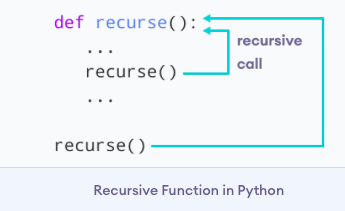

The following recursive examples demonstrate how recursion is implemented in Python.

In [ ]:
import random
import traceback


def get_function_name():
    return traceback.extract_stack(None, 2)[0][2]

# 遞廻函式 1: 求兩整數的最大公約數
def gcd(a, b):
    """ This is a recursive function
    to determin the greatest common divisor among 2 integers
    """
    
    if not isinstance(a, int):
        print(f'{get_function_name()}: Invalid integer {a}!')
        return

    if not isinstance(b, int):
        print(f'{get_function_name()}: Invalid integer {b}!')
        return

    if b == 0:
        return a
    else:
        return gcd(b, a % b)


# Example gcd
if __name__ == '__main__':
    print(f'gcd(16,4) = {gcd(16, 4)}\n')
    print(f'gcd(20,30) = {gcd(20, 30)}\n')


# 遞廻函式 2: 求某一正整數的乘冪 
def factorial(num):
    """ This is a recursive function
    to find the factorial of a positive integer
    """
    
    if isinstance(num, int) and num > 0:
        if num == 1:
            return 1
        return (num * factorial(num - 1))
    else:
        print(f'{get_function_name()}: Invalid positive integer!')


# Example factorial
if __name__ == '__main__':
    num = 7
    print(f'{num}! = {factorial(num)}\n')

    num = 'string'
    print(f'{num}! = {factorial(num)}\n')


### How to build a binary tree using recursion

This is a class node with which a binary search tree can be built.
    The binary search tree has the following properties:

    1. Binary tree can be built by inserting nodes or its key, or
        from a list of keys.
    2. No duplicate key is allowed.
    3. all nodes are placed with keys in an accending ("Inorder") order
    4. Each node with at most two children nodes allowed
    5. Binary tree can be converted to a list in an accending or deccending order
    6. Any node can be removed from binary tree
    7. Any subtree can be removed from binary tree
    8. The entire tree can be removed in a postorder traversal order
    9. The whole tree can be discarded recursively from the root till empty

    Errors that this module might return:

    -1: Node key duplicate
    -2: Node not found

When we implemented a class method of remove_node, we tried to avoid to many recursion and too many tree traversal. Hence the optimized strategy is to consider three possibilities of node location within the binary search tree. 

    1) Node to be removed is the leaf: Simply remove from the tree. 
    
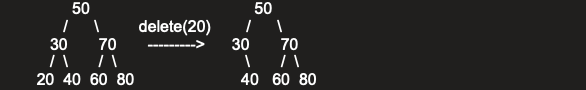

    2) Node to be removed has only one child: Copy the child to the node and remove the child.

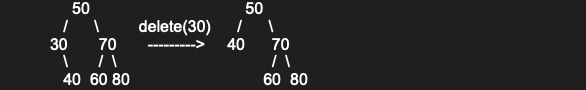
    
    3) Node to be removed has two children: Find inorder successor of the node. Copy contents of the inorder successor to the node and remove the inorder successor. Note that inorder predecessor can also be used. 

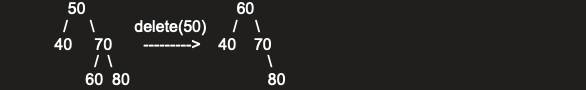


In [ ]:
import random


class biNode:

    # 類別變數:
    # 節點總數，初值0
    count = 0
    root = None

    # 物件實體化
    def __init__(self, value, left=None, right=None):
        self.key = value
        self.left = left
        self.right = right
        biNode.count += 1
        if biNode.count == 1:
            # first node becomes the root node
            biNode.root = self

    def free_node(self):
        """ To delete a biNode object
    Syntax:
        <obj>.free_node()
        return 0
        """

        # unreference the node and let Python performs
        # garbage collection automatically
        self = None

        biNode.count -= 1
        if biNode.count <= 0:
            # btree is empty
            biNode.root = None
            biNode.count = 0
        return 0

    def insert_node(self, node):
        """ To insert a node into a btree, rooted by self
    Syntax:
        <obj>.insert_node(node)
        return:
             0: if successful
            -1: ignore the insertion if duplicate key
        """

        if node.key == self.key:
            # duplicated key
            return -1   # key duplicate

        if node.key < self.key:
            if self.left is None:
                self.left = node
                return 0
            else:
                if self.left.insert_node(node) == -1:
                    return -1
        else:  # i.e node.key > self.key
            if self.right is None:
                self.right = node
                return 0
            else:
                if self.right.insert_node(node) == -1:
                    return -1
        return 0

    def remove_node(self, key):
        """ To remove a node given a key within self sub-tree
    Syntax:
        <obj>.remove_node(key)
        return:
            node to remove if successfully
            -2: node/key not found
        """

        # Base Case
        if key == self.key:

            # Found the node to be removed.

            # If the node is a leaf node
            if self.left is None and self.right is None:
                self.free_node()
                return self

            # If one of the children is empty
            if self.left is None:
                temp = self.right
                self.free_node()
                return temp

            elif self.right is None:
                temp = self.left
                self.free_node()
                return temp

            # If both children exist

            # Find Successor and its parent if any
            succParent = self
            succ = self.right

            while succ.left != None:
                succParent = succ
                succ = succ.left

            # Delete successor.
            # Since successor is always left child of its parent
            # we can safely make successor's right child
            # as left of its parent.

            # If there is no succParent,
            # then assign succ->right to root->right (i.e. succParent == root)
            if succParent != self:
                succParent.left = succ.right
            else:
                succParent.right = succ.right

            # Copy Successor Data to root
            self.key = succ.key
            succ.free_node()

        # Recursive calls for downstream of
        # node to be removed
        else:   # Target node not found yet, recursively go left or right
            if key < self.key:
                # go left
                if self.left is None:
                    return -2   # node not found
                else:   # go left recursively
                    return self.left.remove_node(key)
            else:
                # go right
                if self.right is None:
                    return -2   # node not found
                else:   # go right recursively
                    return self.right.remove_node(key)
        return self

    def find_node(self, key):
        """ Find a node given a key within self subtree
    Syntax:
        <obj>.find_node(key)
        return:
            biNode object if key is found
            -2: if not found
        """
        if key == self.key:
            return self
        elif key < self.key:
            if self.left is None:
                return -2   # key not found
            else:
                return self.left.find_node(key)
        else:  # ie key > self.key
            if self.right is None:
                return -2   # key not found
            else:
                return self.right.find_node(key)

    def find_node_max(self):
        """ Find the node with max key within self subtree
        with its parent and child if any
    Syntax:
        <obj>.find_node_max()
        return 3 parameters:
            1. A biNode object with the max key (ie, max-node)
            2. A parent node of the max-node if any, None otherwise
            3. A child node of the max-node if any, None otherwise
        """

        if self.right is None:   # only 1 generation
            # self has no child on the right, so self is the max-node
            if self.left is None:
                # The max-node is a really leaf node (and no parent)
                return self, None, None
            else:
                # The max-node has a child on the left
                return self, None, self.left
        else:   # self has a child on the right, looking one level down
            # checking if self has a grandchild on the right
            if self.right.right is None:   # 2 generations
                # no grandchild on the right, so self's child is the max-node
                if self.right.left is None:
                    # The max-node does not have a child on the left
                    return self.right, self, None
                else:
                    # The max-node has a child on the left
                    return self.right, self, self.right.left
            else:   # self has a grandchild on the right (3 generations)
                # self right child is not the max yet, recursively down
                return self.right.find_node_max()

    def find_node_min(self):
        """ Find the node with min key within self subtree
        with its parent and child if any
    Syntax:
        <obj>.find_node_min()
        return 3 parameters:
            1. A biNode object with the min key (ie, min-node)
            2. A parent node of the min-node if any, None otherwise
            3. A child node of the min-node if any, None otherwise
        """

        if self.left is None:   # only 1 generation
            # self has no child on the left, so self is the max-node
            if self.right is None:
                # The min-node is a really leaf node (and no parent)
                return self, None, None
            else:
                # The min-node has a child on the right
                return self, None, self.right
        else:   # self has a child on the left, looking one level down
            # checking if self has a grandchild on the right
            if self.left.left is None:   # 2 generations
                # no grandchild on the left, so self's child is the min-node
                if self.left.right is None:
                    # The min-node does not have a child on the right
                    return self.left, self, None
                else:
                    # The min-node has a child on the right
                    return self.left, self, self.left.right
            else:   # self has a grandchild on the left (3 generations)
                # self left child is not the min yet, recursively down
                return self.left.find_node_min()

    def find_node_parent(self, key):
        """ Find a node given a key within self subtree
        with its parent if any and its orientation
        i.e. from parent's left pointer or not.
    Syntax:
        <obj>.find_node_parent(node)
        return: 3 parameters
            Target biNode object with matching key value, None otherwise
            Parent biNode object if exists, None otherwise
            True: Target node is on the parent's left arm, False otherwise
            """

        if key == self.key:
            # target is the root, no parent found
            return None, None, False

        elif key < self.key:
            # check left child
            if self.left is None:
                # target not found, so no parent found either
                return None, None, False

            if key == self.left.key:
                # left child is the target, parent found
                return self.left, self, True

            else:
                # go left
                return self.left.find_node_parent(key)

        else:
            # check right child
            if self.right is None:
                # child not found, so no parent found either
                return None, None, False

            if key == self.right.key:
                # right child is the target, parent found
                return self.right, self, False

            else:
                # go right
                return self.right.find_node_parent(key)

    def print_keys(self, order):
        """ Print all the keys separated by a space
        within self sub-tree in 3 differnt orders
    Syntax:
        <obj>.print_keys(order)
        return:
            sorted string of keys if order = "Inorder"
            postorder string if order = "Postorder"
            preorder string if order = "Preorder"
            None: invalide order
        """

        if order == "Inorder":
            self.print_keys_inorder()

        elif order == "Postorder":
            self.print_keys_postorder()

        elif order == "Preorder":
            self.print_keys_preorder()

        else:
            print(f'Invalid order: {order}')

    def print_keys_inorder(self):

        if self.left is not None:
            self.left.print_keys_inorder()

        print(self.key, end=' ')

        if self.right is not None:
            self.right.print_keys_inorder()

    def print_keys_postorder(self):

        if self.left is not None:
            self.left.print_keys_postorder()

        if self.right is not None:
            self.right.print_keys_postorder()

        print(self.key, end=' ')

    def print_keys_preorder(self):

        print(self.key, end=' ')

        if self.left is not None:
            self.left.print_keys_preorder()

        if self.right is not None:
            self.right.print_keys_preorder()

    def sort_keys(self, reverse=False):
        """ Traverse the btree (Inorder) to retrieve sorted keys
        in accending order if reverse=False (by default), or
        in decending order if reverse=True.
    Syntax:
        <obj>.sort_keys(reverse)
        return:
            A sorted list of keys
        """
        key_list = []
        self.append_key(key_list, reverse)
        return key_list

    def append_key(self, key_list, reverse=False):
        """ Internal recursive function, invoked by sort_keys()
        to append all the keys in a list
    Syntax:
        <obj>.append_key(node_list, reverse)
        return 0
        """

        if reverse is False:
            if self.left is not None:
                self.left.append_key(key_list, reverse)

            key_list.append(self.key)

            if self.right is not None:
                self.right.append_key(key_list, reverse)
        else:
            if self.right is not None:
                self.right.append_key(key_list, reverse)

            key_list.append(self.key)

            if self.left is not None:
                self.left.append_key(key_list, reverse)

    def sort_nodes(self, reverse=False):
        """ Traverse the btree (Inorder) to retrieve nodes with key sorted
        in accending order if reverse=False (by default), or
        in decending order if reverse=True
    Syntax:
        <obj>.sort_nodes(reverse)
        return:
            A sorted list of nodes
        """

        node_list = []
        self.append_node_inorder(node_list, reverse)
        return node_list

    def append_node_inorder(self, node_list, reverse=False):
        """ Internal recursive function, invoked by sort_nodes()
        to append all the nodes in a list
    Syntax:
        <obj>.append_node_inorder(node_list, reverse)
        return 0
        """

        if reverse is False:
            if self.left is not None:
                self.left.append_node_inorder(node_list, reverse)

            node_list.append(self)

            if self.right is not None:
                self.right.append_node_inorder(node_list, reverse)

        else:   # ie in reverse order
            if self.right is not None:
                self.right.append_node_inorder(node_list, reverse)

            node_list.append(self)

            if self.left is not None:
                self.left.append_node_inorder(node_list, reverse)

        return 0

    def append_node_postorder(self, node_list):
        """ Append nodes in a postorder traversal manner
        i.e. left, right and self ordr
    Syntax:
        <obj>.append_postorder(node_list)
        return 0
        """

        if self.left is not None:
            self.left.append_node_postorder(node_list)

        if self.right is not None:
            self.right.append_node_postorder(node_list)

        node_list.append(self)

    def append_node_preorder(self, node_list):
        """ Append nodes in a preorder traversal manner
        i.e. self, left, right ordr
    Syntax:
        <obj>.append_postorder(node_list)
        return 0
        """

        node_list.append(self)

        if self.left is not None:
            self.left.append_node_preorder(node_list)

        if self.right is not None:
            self.right.append_node_preorder(node_list)

    def remove_tree(self):
        """ Free up all nodes within self subtree
        by removing all the nodes
        with leaf node first,
        i.e. in a postorder traversal manner.
    Syntax:
        <obj>.remove_tree()
        return: 0
        """

        # if self is not the root, we need to
        # cut the subtree out of main tree prior to removal.
        node_found, node_p, from_left = biNode.root.find_node_parent(self.key)

        if node_p is not None:
            if from_left:
                node_p.left = None
            else:
                node_p.right = None

        list_stack = []
        self.append_node_postorder(list_stack)

        for node in list_stack:
            self.remove_node(node.key)

        return 0

    @classmethod
    def insert_tree(cls, key):
        """ To create a node give a key and
        insert the node into a btree from the root
    Syntax:
        <obj>.insert_node(node)
        return:
            A new node if successful, or
            An existed node with the duplicate key
        """

        # If the tree is empty,
        # return a new node
        if biNode.root is None:
            return biNode(key)

        # Otherwise check any node with the key down the tree
        node_found = biNode.root.find_node(key)
        if node_found == -2:
            # create a new node
            node_new = biNode(key)

            # insert new node into btree
            biNode.root.insert_node(node_new)
            return node_new
        else:
            # return node that already exist with the same key
            return node_found

    @classmethod
    def discard_tree(cls):
        """ Free up all the nodes within the whole btree
        with the root first strategy
        till the btree is empty
    Syntax:
        biNode.discard_tree()
        return: 0
        """

        if cls.root is None:
            return 0
        else:
            cls.root.remove_node(biNode.root.key)

        if cls.root is not None:
            return cls.root.discard_tree()
        else:
            return 0


if __name__ == '__main__':
    """ Example code, demonstrating:
        Build a binary tree with random numbers
        1. Plus root node with key of 500
        2. With keys of 9 random-number keys between 100 and 999
        3. Showing btree in 3 orders
        4. Converting btree to a sorted list in accending order
        5. Converting btree to a sorted list in decending order
        6. Removing the whole tree
    """

    node_root = biNode.insert_tree(500)
    print(
        f'Example 1: Binary Tree root at {node_root} with key = {node_root.key}\n')

    for _ in range(9):
        bn = biNode.insert_tree(random.randint(100, 999))
        print(f'Example 2: Node at {bn} inserted with key = {bn.key}')
    print()

    print(f'Example 3: Number of nodes in btree = {biNode.count}')
    print(f'Example 3.1: printing keys Inorder:')
    node_root.print_keys("Inorder")
    print('\n')

    print(f'Example 3.2: printing keys Postorder:')
    node_root.print_keys("Postorder")
    print('\n')

    print(f'Example 3.3: printing keys Preorder:')
    node_root.print_keys("Preorder")
    print('\n')

    # Converting binary tree to list
    new_list = node_root.sort_keys()
    print(f'Example 4: sorted key-list:\n {new_list}\n')
    rev_list = node_root.sort_keys(reverse=True)
    print(f'Example 5: reverse-sorted key-list:\n {rev_list}\n')

    # Discard the whole tree
    print(
        f'Example 6: Discarding btree, root at {biNode.root} with key = {biNode.root.key}')
    biNode.discard_tree()
    print(f'Example 6: The whole tree discarded. Program terminated.')


Example 1: Binary Tree root at <__main__.biNode object at 0x7fef58fa5400> with key = 500

Example 2: Node at <__main__.biNode object at 0x7fef59046f70> inserted with key = 515
Example 2: Node at <__main__.biNode object at 0x7fef590462e0> inserted with key = 928
Example 2: Node at <__main__.biNode object at 0x7fef590461c0> inserted with key = 504
Example 2: Node at <__main__.biNode object at 0x7fef58f99250> inserted with key = 964
Example 2: Node at <__main__.biNode object at 0x7fef58f99130> inserted with key = 521
Example 2: Node at <__main__.biNode object at 0x7fef58f998e0> inserted with key = 136
Example 2: Node at <__main__.biNode object at 0x7fef58f99c10> inserted with key = 597
Example 2: Node at <__main__.biNode object at 0x7fef58f76ca0> inserted with key = 644
Example 2: Node at <__main__.biNode object at 0x7fef58f76a90> inserted with key = 488

Example 3: Number of nodes in btree = 10
Example 3.1: printing keys Inorder:
136 488 500 504 515 521 597 644 928 964 

Example 3.2: pri

### Example Code: Binary tree implementation

Based on the class biNode we defined above, in the "bsTree.py" file. 

The following example code, demonstrating:
   
    1. Build a binary tree from a list of integers
    2. Showing btree info:
        1) print keys in "Inorder" order
        2) print keys in "Postorder" order
        3) print keys in "Preorder" order
        4} sort keys stored in a list
    3. Finding out
        1) max node of the btree
        2) min node of the btreetree
        3) max node of a sub-tree
        4) min node of a sub-tree
    4. Finding a node given a key
        1) finding a node with matching key
        2) finding target node with matching key and its parent if any
    5. Removing a node given a key
    6. Removing a subtree
    7. Removing an entire tree


In [ ]:
from bsTree import biNode
import glog as log

# log.setLevel("DEBUG")
numbers = [30, 70, 20, 40, 60, 80, 80, 50]
print(f'Number of items in {numbers} = {len(numbers)}\n')

# create root of binary tree
node_root = biNode.insert_tree(numbers.pop())
print(f'Example 1: Built a binary tree with root key = {biNode.root.key}')

# To iterate from the rest elements in the list
for key in numbers:
    bn = node_root.insert_tree(key)
    print(f'Example 1: Node at {bn} inserted with key = {bn.key}')
print()

# print keys
print(f'Example 2.1: printing keys Inorder:', end=' ')
node_root.print_keys("Inorder")
print()
print(f'Example 2.2: printing keys Postorder:', end=' ')
node_root.print_keys("Postorder")
print()
print(f'Example 2.3: printing keys Preorder:', end=' ')
node_root.print_keys("Preorder")
print()

# To print the sorted keys in a list
print(
    f'Example 2.4: sorting keys of the whole btree: {biNode.root.sort_keys()} with {biNode.count} node(s)')
print(f'root at {biNode.root} with key = {biNode.root.key}\n')

# To print the max node and key
node_max, _, _ = node_root.find_node_max()
print(f'Example 3.1: global maximum key = {node_max.key} at {node_max}')

# To print the min node and key
node_min, _, _ = node_root.find_node_min()
print(f'Example 3.2: global mainimum key = {node_min.key} at {node_min}\n')

# Example: To find a node from btree given a key
key = 30
node_found = node_root.find_node(key)
if node_found != -2:
    node_max, _, _ = node_found.find_node_max()
    print(
        f'Example 3.3: Subtree of {key} has a local maximum key = {node_max.key} at {node_max}')
    node_min, _, _ = node_found.find_node_min()
    print(
        f'Example 3.4: Subtree of {key} has a local minimum key = {node_min.key} at {node_min}\n')
    print(f'Example 4.1: Finding target node with key = {key}')
    print(f'---> Found {node_found} with key= {node_found.key}\n')

else:
    print(f'---> key = {key} not found\n')

key = 30
print(f'Example 4.2: Finding a node with key = {key} and its parent if any')
node_found, node_p, from_left = node_root.find_node_parent(key)
if node_found is None:
    print(f'---> key = {key} not found.')
    if node_p is None:
        print(f'---> parent node not found.\n')
    else:
        print(f'---> Found parent {node_p} with key= {node_p.key}\n')
else:
    print(f'---> Found target {node_found} with key= {node_found.key}')
    if node_p is None:
        print(f'---> parent node not found.\n')
    else:
        print(f'---> Found parent {node_p} with key= {node_p.key}\n')

# Example: To remove a node from btree given a key
key = 50
print(f'Example 5: Removing target node with key = {key}')

node_removed = node_root.remove_node(key)
if node_removed == -2:
    print(f'key = {key} not found.\n')
else:
    print(f'node at {node_removed} with key = {key} removed successfully.')
    print(f'{biNode.root.sort_keys()} with {biNode.count} node(s)')
    print(f'root at {biNode.root} with key = {biNode.root.key}\n')

# Removing a subtree
key = 70
node_found = node_root.find_node(key)
if node_found == -2:   # not found
    print(f'Example 6: Removing a sub-btree, invalid key = {key}\n')
else:
    print(
        f'Example 6: Removing a sub-btree of {node_found.key} at {node_found}')
    node_found.remove_tree()
    print(f'{biNode.root.sort_keys()} with {biNode.count} node(s)\n')

# Removing the entire tree
print(
    f'Example 7: Removing an entire btree, root at {biNode.root} with key = {biNode.root.key}')
node_root.remove_tree()
if biNode.root is None and biNode.count == 0:
    print(f'The entire tree removed. Program terminated.')


Number of items in [30, 70, 20, 40, 60, 80, 80, 50] = 8

Example 1: Built a binary tree with root key = 50
Example 1: Node at <bsTree.biNode object at 0x7fef58f3e6a0> inserted with key = 30
Example 1: Node at <bsTree.biNode object at 0x7fef58da85e0> inserted with key = 70
Example 1: Node at <bsTree.biNode object at 0x7fef58dbc1c0> inserted with key = 20
Example 1: Node at <bsTree.biNode object at 0x7fef58f98730> inserted with key = 40
Example 1: Node at <bsTree.biNode object at 0x7fef58f98d30> inserted with key = 60
Example 1: Node at <bsTree.biNode object at 0x7fef58f98c40> inserted with key = 80
Example 1: Node at <bsTree.biNode object at 0x7fef58f98c40> inserted with key = 80

Example 2.1: printing keys Inorder: 20 30 40 50 60 70 80 
Example 2.2: printing keys Postorder: 20 40 30 60 80 70 50 
Example 2.3: printing keys Preorder: 50 30 20 40 70 60 80 
Example 2.4: sorting keys of the whole btree: [20, 30, 40, 50, 60, 70, 80] with 7 node(s)
root at <bsTree.biNode object at 0x7fef58da2

## 4. Decorators

Decorators in Python are a very powerful and useful tool in Python since it allows programmers to modify the behavior of function or class. 

Decorators allow us to wrap another function in order to extend the behavior of the wrapped function, without permanently modifying it. 

But before diving deep into decorators let us understand some concepts that will come in handy in learning the decorators.

Properties of functions:

	1. A function is an instance of object type. so it can be stored in a variable.
	2. You can pass the function as a parameter to another function.
    3. You can return the function from a function.


In [ ]:
# Example 1: to illustrate functions can be treated as objects 

def shout(text): 

    return f'Function shout() returns: {text.upper()}'
 

print(shout("Hello")) 
 

yell = shout 
 
print(f'Function "shout" can be treated as an object in "yell" variable:\n---> {yell}')
print(yell("Hello")) 


In [ ]:
# Example 2: to illustrate functions can be passed as arguments to other functions 

def shout(text): 

    return f'Function shout() returns: {text.upper()}'
 

def whisper(text): 

    return f'Function whisper() returns: {text.lower()}' 


def greet(func): 

    # storing the function in a variable 

    greeting = func("""Hi, I am created by a function passed as an argument.""") 

    print (greeting) 

greet(shout) 
greet(whisper) 


In [ ]:
# Example 3: to illustrate functions can return another function 

def create_adder(x): 

    def adder(y): 

        return x+y 
 

    return adder 
 
print(f'create_adder ---> {create_adder}\n')

add_15 = create_adder(15) 
 
print(f'1. create_adder(15) returns executed adder(15) to a variable add_15')
print(f'add_15 ---> {add_15}\n')
print(f'2. add_15(10) calls create_adder(15) function, returning: {add_15(10)}\n')


## 5. Using "glog" Module for simple logging

The "logging" module earlier for logging. This "glog" Module was introduced to serve the same purpose as well.

However, in particular this is a simple Google-style logging wrapper for Python.

This library attempts to greatly simplify logging in Python applications.

Nobody wants to spend hours pouring over the PEP 282 logger documentation, and almost nobody actually needs things like loggers that can be reconfigured over the network.  We just want to get on with writing our apps.

### 5.1 Core benefits

	1. You and your code don't need to care about how logging works. Unless you want to, of course.
	
	2. No more complicated setup boilerplate!
	
	3. Your apps and scripts will all have a consistent log format, and the same predictable behaviours.
	
	4. This library configures the root logger, so nearly everything you import that uses the standard Python logging module will play along nicely.

### 5.2 Behaviors

	1. Messages are always written to stderr.
	
	2. Lines are prefixed with a google-style log prefix, of the form:

#### E0924 22:19:15.123456 19552 filename.py:87] Log message...

Splitting on spaces, the fields are:

	1. First character is the log level, followed by MMDD (month, day)
	2. HH:MM:SS.microseconds
	3. Process ID
	4. basename_of_sourcefile.py:linenumber]
	5. Body of the log message begins here

### 5.3 Check assert helpers

Like the C++ version of glog`_, python-glog provides a set of check macros that help document and enforce invariants.  

These provide a detailed message indicating what values caused the assertion to fail, along with a stack trace identifying the code-path that caused the failure, hopefully making it easier to reproduce the error.  

Failed checks raise the FailedCheckException.

You may find these more convenient and/or more familiar than standard Python asserts, particularly if you are working in a mixed C++ and Python codebase.

Provided check functions:

    check(condition)
    check_eq(obj1, obj2)
    check_ne(obj1, obj2)
    check_le(obj1, obj2)
    check_ge(obj1, obj2)
    check_lt(obj1, obj2)
    check_gt(obj1, obj2)
    check_notnone(obj1, obj2)

In [ ]:
import glog as log
import math

def compute_something(a):
    log.check_eq(type(a), float) # require floating point types
    log.check_ge(a, 0) # require non-negative values
    value = math.sqrt(a)
    return value

if __name__ == '__main__':
    
    # assert success
    number = 9.0
    print(f'sqrt({number}) = {compute_something(number)}\n')
    
    # assert failure
    number = 9
    print(f'sqrt({number}) = {compute_something(number)}\n')



F1026 09:58:26.960628 7932 1341112718.py:5] Check failed: <class 'int'> != <class 'float'>
D1026 09:58:26.961019 7932 1341112718.py:5] Check failed here:
D1026 09:58:26.961420 7932 1341112718.py:5] 	<frozen runpy>::_run_module_as_main:198	
D1026 09:58:26.961764 7932 1341112718.py:5] 	<frozen runpy>::_run_code:88	
D1026 09:58:26.961936 7932 1341112718.py:5] 	ipykernel_launcher.py::<module>:18	app.launch_new_instance()
D1026 09:58:26.962153 7932 1341112718.py:5] 	application.py::launch_instance:1075	app.start()
D1026 09:58:26.962352 7932 1341112718.py:5] 	kernelapp.py::start:739	self.io_loop.start()
D1026 09:58:26.962517 7932 1341112718.py:5] 	asyncio.py::start:211	self.asyncio_loop.run_forever()
D1026 09:58:26.962649 7932 1341112718.py:5] 	base_events.py::run_forever:683	self._run_once()
D1026 09:58:26.962787 7932 1341112718.py:5] 	base_events.py::_run_once:2040	handle._run()
D1026 09:58:26.962951 7932 1341112718.py:5] 	events.py::_run:89	self._context.run(self._callback, *self._args)
D

D1026 09:58:26.963578 7932 1341112718.py:5] 	ipkernel.py::execute_request:362	await super().execute_request(stream, ident, parent)
D1026 09:58:26.963695 7932 1341112718.py:5] 	kernelbase.py::execute_request:778	reply_content = await reply_content
D1026 09:58:26.963983 7932 1341112718.py:5] 	ipkernel.py::do_execute:449	res = shell.run_cell(
D1026 09:58:26.964322 7932 1341112718.py:5] 	zmqshell.py::run_cell:549	return super().run_cell(*args, **kwargs)
D1026 09:58:26.964457 7932 1341112718.py:5] 	interactiveshell.py::run_cell:3098	result = self._run_cell(
D1026 09:58:26.964812 7932 1341112718.py:5] 	interactiveshell.py::_run_cell:3153	result = runner(coro)
D1026 09:58:26.965027 7932 1341112718.py:5] 	async_helpers.py::_pseudo_sync_runner:128	coro.send(None)
D1026 09:58:26.965180 7932 1341112718.py:5] 	interactiveshell.py::run_cell_async:3365	has_raised = await self.run_ast_nodes(code_ast.body, cell_name,
D1026 09:58:26.965306 7932 1341112718.py:5] 	interactiveshell.py::run_ast_nodes:3610	

sqrt(9.0) = 3.0



FailedCheckException: Check failed: <class 'int'> != <class 'float'>

### 5.4 Performance Testing

Let's Combine precious two sections, decorator and logging, into an application to measure the execution turnaround time of any program.

In Performance testing, to be able to measure a critical component's turnaround time is a must. In Python, we can leverage both logging and function decorator to implement this requirement.

The function under test can be wrapped in a time decorator to measure the elapse time between the function in and out and use logging (glog in this example) to collect all the measurement data.


In [ ]:
import glog as log
import datetime

class inAndOutLog():
    def __init__(self, funcName):
        self.funcName = funcName

    def __enter__(self):
        log.info(f'\tIn: {self.funcName}')
        self.init_time = datetime.datetime.now()
        return self

    def __exit__(self, type, value, tb):
        log.info(f'\tOut: {self.funcName} took {datetime.datetime.now() - self.init_time} seconds')
        
def func_timer_decorator(func):

    def func_wrapper(*args, **kwargs):
        with inAndOutLog(func.__name__):
            return func(*args, **kwargs)
    return func_wrapper

def gen_func(nums):
    for n in nums:
        yield n * n * n

@func_timer_decorator
def time_gen(nums):
    # using generator
    my_gen = gen_func(nums)
    print(f'Generator: {my_gen}\n')
    
    for num in my_gen:
      print(num)

@func_timer_decorator
def time_tuple(nums):
    # using tuple comprehension
    my_gen2 = (n * n * n for n in nums)
    print(f'Tuple comprehension: {my_gen2}\n')

    for num in my_gen2:
      print(num)


@func_timer_decorator
def time_list(nums):
    # using list comprehension
    my_gen3 = [n * n * n for n in nums]
    print(f'List comprehension: {my_gen3}\n')

    for num in my_gen3:
      print(num)


log.setLevel("INFO")
numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

log.info('Performance testing: generator function:')
time_gen(numbers)

log.info('Performance testing: tuple comprehension:')
time_tuple(numbers)

log.info('Performance testing: list comprehension:')
time_list(numbers)


## 6. Using "Functools" Module

### 6.1 @lru_cache - Memoization (Caching)

Decorator to wrap a function with a memoizing callable that saves up to the maxsize most recent calls. It can save time when an expensive or I/O bound function is periodically called with the same arguments.

The cache is threadsafe so that the wrapped function can be used in multiple threads. This means that the underlying data structure will remain coherent during concurrent updates.

In [ ]:
# @lru_cache - Memoization (Caching)
from functools import lru_cache

# Expensive recursive Fibonacci without cache
def fib_recursive(n):
    if n < 2:
        return n
    return fib_recursive(n-1) + fib_recursive(n-2)

# With LRU cache - dramatically improves performance
@lru_cache(maxsize=128)
def fib_cached(n):
    if n < 2:
        return n
    return fib_cached(n-1) + fib_cached(n-2)

# Demo
import time
start = time.time()
print(f"Fib(35) without cache: {fib_recursive(35):,}")  # Slow!
print(f"Time: {time.time() - start:.4f}s")
start = time.time()
print(f"Fib(35) with cache: {fib_cached(35):,}")  # Fast!
print(f"Time: {time.time() - start:.4f}s")


Fib(35) without cache: 9,227,465
Time: 0.5627s
Fib(35) with cache: 9,227,465
Time: 0.0000s


### 6.2 @cache - Unlimited LRU Cache (Python 3.9+)

Returns the same as lru_cache(maxsize=None), creating a thin wrapper around a dictionary lookup for the function arguments. Because it never needs to evict old values, this is smaller and faster than lru_cache() with a size limit.

In [ ]:
from functools import cache
import time

@cache  # Unlimited cache size
def expensive_lookup(key):
    print(f"Computing for key: {key}")
    # Simulate expensive computation
    time.sleep(1)
    return key * 2

# First call computes
print("First call: computing for key=5, return 10")
start = time.time()
print(expensive_lookup(5))  # Computing for key: 5, returns 10
print(f"Time: {time.time() - start:.4f}s")

print("Second call: returns 10 instantly (cached)")
start = time.time()
print(expensive_lookup(5))  # Returns 10 instantly (cached)
print(f"Time: {time.time() - start:.4f}s")

print("Third call: computing for key=7, return 14")
start = time.time()
print(expensive_lookup(7))  # Computing for key: 7, returns 14
print(f"Time: {time.time() - start:.4f}s")


First call: computing for key=5, return 10
Computing for key: 5
10
Time: 1.0053s
Second call: returns 10 instantly (cached)
10
Time: 0.0000s
Third call: computing for key=7, return 14
Computing for key: 7
14
Time: 1.0011s


### 6.3 ached_property - Cached Property (Python 3.8+)

This decorator is designed to cache the result of a method call as an instance attribute. It acts similarly to @property but with the added functionality of caching.


In [ ]:
from functools import cached_property
import time

class ExpensiveClass:
    def __init__(self, data):
        self._data = data
    
    @cached_property
    def processed_data(self):
        print("Expensive computation running...")
        # Simulate expensive processing
        time.sleep(2)
        return sorted(self._data)
    
    def reset_cache(self):
        """Manual cache invalidation"""
        if 'processed_data' in self.__dict__:
            del self.__dict__['processed_data']

obj = ExpensiveClass([3, 1, 4, 1, 5])
print("First access: compute once")
start = time.time()
print(obj.processed_data)  # Computes once: [1, 1, 3, 4, 5]
end = time.time()
print(f"Time taken: {end - start:.2f} seconds")

print("Second access: cached result, instant")
start = time.time()
print(obj.processed_data)  # Cached result, instant
end = time.time()
print(f"Time taken: {end - start:.2f} seconds")

obj.reset_cache()
print("Third access: recomputes after reset")
start = time.time()
print(obj.processed_data)  # Recomputes after reset
end = time.time()
print(f"Time taken: {end - start:.2f} seconds")


First access: compute once
Expensive computation running...
[1, 1, 3, 4, 5]
Time taken: 2.00 seconds
Second access: cached result, instant
[1, 1, 3, 4, 5]
Time taken: 0.00 seconds
Third access: recomputes after reset
Expensive computation running...
[1, 1, 3, 4, 5]
Time taken: 2.01 seconds


### 6.4 partial - Partial Function

This function is used for a function which “freezes” some portion of a function's arguments and/or keywords resulting in a new simple function object.

In [ ]:
from functools import partial

def power(base, exponent):
    return base ** exponent

# Create simple functions from power()
print("Create simple functions")
square = partial(power, exponent=2)
cube = partial(power, exponent=3)
print("\tsquare(4) =", square(4))  # 16
print("\tcube(3) =", cube(3))    # 27

# With keyword arguments from power()
print("\nWith keyword arguments")
multiply_by_10 = partial(lambda x, y: x * y, y=10)
print("\tmultiply_by_10(5) =", multiply_by_10(5))  # 50


Create simple functions
	square(4) = 16
	cube(3) = 27

With keyword arguments
	multiply_by_10(5) = 50


### 6.5 reduce - Reduce Function

The "reduce" function applies to an iterable object to obtain a cumulative result by traversing all the items of an iterable.

In [ ]:
from functools import reduce

# Sum of list using reduce
numbers = [1, 2, 3, 4, 5]
total = reduce(lambda x, y: x + y, numbers)
print(f"Sum: {total}")  # 15

# Product of list
product = reduce(lambda x, y: x * y, numbers)
print(f"Product: {product}")  # 120

# Custom reduction - finding maximum with index
data = [(10, 'a'), (5, 'b'), (15, 'c'), (2, 'd')]

max_with_index = reduce(lambda x, y: x if x[0] > y[0] else y, data)
print(f"Max value: {max_with_index}")  # (15, 'c')


Sum: 15
Product: 120
Max value: (15, 'c')


### 6.6 @wraps - Preserving Function Metadata

The @wraps decorator is used to preserve the metadata of the original function when it is decorated.

In [ ]:
from functools import wraps
import time

def timer(func):
    @wraps(func)  # Preserves original function's metadata
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        print(f"{func.__name__} took {time.time() - start:.4f}s")
        return result
    return wrapper

@timer
def slow_function(n):
    """This simulates a slow function that does complex calculations."""
    time.sleep(1)
    return n * n

print("slow_function(10) =", slow_function(10))
print("slow_function.__name__ =", slow_function.__name__)  # 'slow_function' (not 'wrapper')
print("slow_function.__doc__ =", slow_function.__doc__)   # Original docstring preserved
print("\n")
# Without @wraps:
def timer_no_wraps(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        print(f"{func.__name__} took {time.time() - start:.4f}s")
        return result
    return wrapper

@timer_no_wraps
def test_no_wraps_func():
    """Test function"""
    time.sleep(1)
    return 42
print("test_no_wraps_func() =", test_no_wraps_func())
print("test_no_wraps_func.__name__ =", test_no_wraps_func.__name__)  # 'wrapper' ❌
print("test_no_wraps_func.__doc__ =", test_no_wraps_func.__doc__)   # None ❌


slow_function took 1.0051s
slow_function(10) = 100
slow_function.__name__ = slow_function
slow_function.__doc__ = This simulates a slow function that does complex calculations.


test_no_wraps_func took 1.0024s
test_no_wraps_func() = 42
test_no_wraps_func.__name__ = wrapper
test_no_wraps_func.__doc__ = None


### 6.7 total_ordering - Automatic Comparison Methods

The `total_ordering` is a class decorator that simplifies the implementation of rich comparison methods for a class. When applied to a class, it automatically generates the remaining rich comparison methods (__lt__, __le__, __gt__, __ge__) based on the definition of __eq__ and at least one of the other ordering methods (__lt__, __le__, __gt__, or __ge__).

In [ ]:
from functools import total_ordering
from dataclasses import dataclass

@total_ordering
@dataclass
class Person:
    name: str
    age: int
    
    # Only need to implement __lt__ and __eq__
    def __lt__(self, other):
        return self.age < other.age
    
    def __eq__(self, other):
        return self.age == other.age and self.name == other.name

p1 = Person("Alice", 30)
print("p1: ", p1)
p2 = Person("Bob", 25)
print("p2: ", p2)
p3 = Person("Charlie", 30)
print("p3: ", p3)

print("p1 > p2? ", p1 > p2)        # True (uses __gt__ automatically)
print("p1 <= p3? ", p1 <= p3)       # False (uses __le__ automatically)
print("p1 >= p2? ", p1 >= p2)       # True
print("sorted([p2, p1, p3]):\n", sorted([p1, p2, p3]))  # Works with sort!



p1:  Person(name='Alice', age=30)
p2:  Person(name='Bob', age=25)
p3:  Person(name='Charlie', age=30)
p1 > p2?  True
p1 <= p3?  False
p1 >= p2?  True
sorted([p2, p1, p3]):
 [Person(name='Bob', age=25), Person(name='Alice', age=30), Person(name='Charlie', age=30)]


### 6.8 singledispatch - Single Dispatch Generic Functions

The `singledispatch` is a decorator that provides a way to define functions that can handle different types of arguments based on their types.


In [ ]:
from functools import singledispatch
from numbers import Number
import json

@singledispatch
def to_json(obj):
    raise NotImplementedError(f"No converter for {type(obj)}")
@to_json.register
def _(obj: str) -> str:
    return json.dumps({"type": "string", "value": obj})
@to_json.register
def _(obj: Number) -> str:
    return json.dumps({"type": "number", "value": float(obj)})
@to_json.register
def _(obj: list) -> str:
    return json.dumps({"type": "list", "items": [to_json(i) for i in obj]})

# Usage
print("to_json: str type")
print(to_json("hello"))  # {"type": "string", "value": "hello"}

print("\nto_json: Number type")
print(to_json(42))       # {"type": "number", "value": 42.0}

print("\nto_json: list type")
print(to_json([1, "two", 3]))  # Nested conversion


to_json: str type
{"type": "string", "value": "hello"}

to_json: Number type
{"type": "number", "value": 42.0}

to_json: list type
{"type": "list", "items": ["{\"type\": \"number\", \"value\": 1.0}", "{\"type\": \"string\", \"value\": \"two\"}", "{\"type\": \"number\", \"value\": 3.0}"]}


### 6.9 Practical Combined Example

In [ ]:
from functools import lru_cache, partial, wraps
import time

# Combining multiple functools utilities
def retry(max_attempts=3, delay=1):
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            for attempt in range(max_attempts):
                try:
                    return func(*args, **kwargs)
                except Exception as e:
                    if attempt == max_attempts - 1:
                        raise
                    print("Attempted:", attempt)
                    time.sleep(delay * (2 ** attempt))  # Exponential backoff
            return None
        return wrapper
    return decorator

# Production-ready cached function with retry
@lru_cache(maxsize=1000)
@retry(max_attempts=3, delay=0.1)
def fetch_weather(city: str) -> dict:
    # Simulate API call with occasional failure
    if city == "broken" and time.time() % 10 < 2:
        raise ConnectionError("API down")
    return {"city": city, "temp": 72 + hash(city) % 10}

# Usage
print(fetch_weather("New York"))
print(fetch_weather("London"))
print(fetch_weather("broken"))  # Will retry up to 3 times


{'city': 'New York', 'temp': 75}
{'city': 'London', 'temp': 81}
{'city': 'broken', 'temp': 75}
